# Banking Intent Classifier: Portfolio Project
## Exploring the ([CRISP-DM Framework](https://www.datascience-pm.com/crisp-dm-2/))

## Phase 1: Business Understanding

**Goal:** Automate classification of customer banking queries into 77 predefined text categories to improve routing speed, reduce manual triage, and increase first response accuracy. 

**Models being used:**
- Baseline: Multi-Layer Perceptron (MLP) using TF-IDF features
- Advanced: RoBERTa finetuned with LoRA (Low-Rank Adaptation)

## Phase 2: Data Understanding & Exploratory Data Analysis

**Data:** Banking77 dataset from codeacademy.

I will do some exploratory data analysis on the Banking77 dataset to understand its contents before doing any ML.

**Steps:**
- Load and verify both the training and test datasets
- Inspect class distribution across all 77 text categories
- Analyze query text lengths across text classes
- Identify common and distringuishing words per text class
- Document key findings to inform the preprocessing and modeling strategy


In [1]:
# Clone repo into Colab's server
import os, subprocess
repo_path = "/content/banking-intent-classifier"
if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/ovesa/banking-intent-classifier", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

os.chdir(repo_path)

# Install dependencies
%pip install -r requirements.txt
%pip install peft

  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached pandas-2.3.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (91 kB)
  Using cached scipy-1.15.3-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scikit_learn-1.7.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached numexpr-2.10.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.2 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached matplotlib-3.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached torch-2.4.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvisio

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re

from plot_style import set_plot_style
set_plot_style()
sns.set_theme(style="whitegrid", palette="muted")

In [3]:
# Load the data
train_df = pd.read_csv("datasets/banking77_train.csv")
test_df = pd.read_csv("datasets/banking77_test.csv")

# Verification of the data
print(f"Train set shape: {train_df.shape}")
print(f"Train set columns: {train_df.columns}")
print(f"Missing values in train set:\n{train_df.isnull().sum()}\n")
print(f"Unique text in train set: {train_df['text'].nunique()}")

print(f"Test set shape: {test_df.shape}")
print(f"Test set columns: {test_df.columns}")
print(f"Missing values in test set:\n{test_df.isnull().sum()}\n")
print(f"Unique text in test set: {test_df['text'].nunique()}")

print("Sample data")
train_df.head(6)

Train set shape: (10003, 2)
Train set columns: Index(['text', 'category'], dtype='object')
Missing values in train set:
text        0
category    0
dtype: int64

Unique text in train set: 10003
Test set shape: (3080, 2)
Test set columns: Index(['text', 'category'], dtype='object')
Missing values in test set:
text        0
category    0
dtype: int64

Unique text in test set: 3080
Sample data


,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
5,When did you send me my new card?,card_arrival


In [4]:
# verification of category distribution
print(f"Unique text classes: {train_df['category'].nunique()}")
print("Samples per class (train):")
print(train_df['category'].value_counts().describe())

print("Samples per class (test):")
print(test_df['category'].value_counts().describe())

Unique text classes: 77
Samples per class (train):
count     77.000000
mean     129.909091
std       32.942207
min       35.000000
25%      112.000000
50%      127.000000
75%      159.000000
max      187.000000
Name: count, dtype: float64
Samples per class (test):
count    77.0
mean     40.0
std       0.0
min      40.0
25%      40.0
50%      40.0
75%      40.0
max      40.0
Name: count, dtype: float64


### Finding: Class Distribution

- 77 classes are seen in both training and test datast
- Training set has about ~130 samples per class on average
- Test set is balanced at 40 samples per class
- No class imbalance

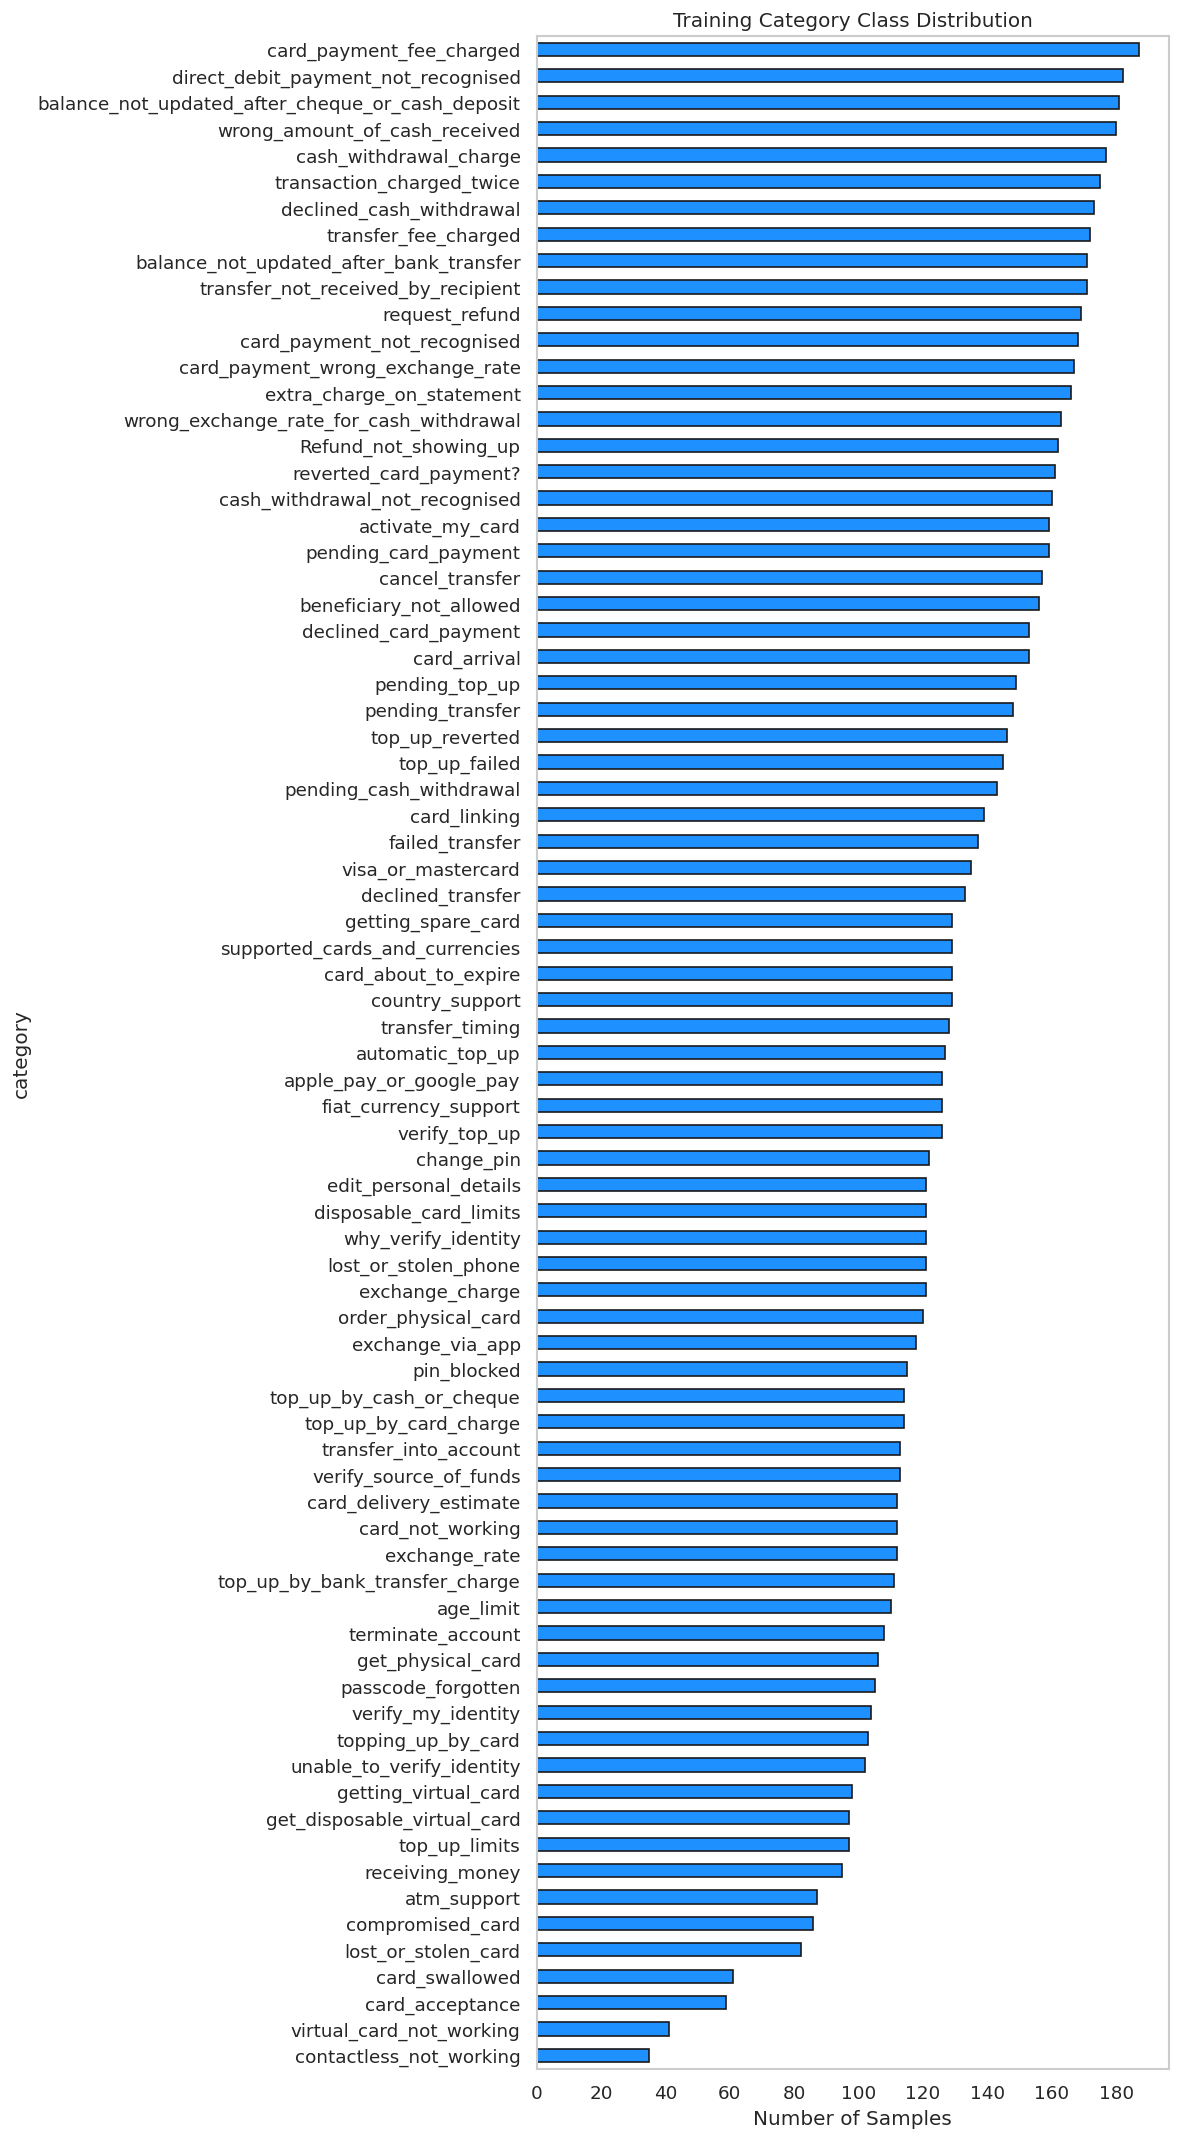

In [6]:
# Visualize the distribution of category classes in the training set

category_counts = train_df['category'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 18))
category_counts.plot(kind='barh', ax=ax, color='dodgerblue', edgecolor='k')

ax.set_xlabel("Number of Samples")
ax.set_title("Training Category Class Distribution")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.grid(False)
plt.tight_layout()
plt.show()

## Finding: Category Training Class Distribution

- Most sampled categories: `card_payment_fee_charged`, `direct_debit_payment_not_recognised`, etc
- Least sampled categories: `contactless_not_working`, `virtual_card_not_working`, etc

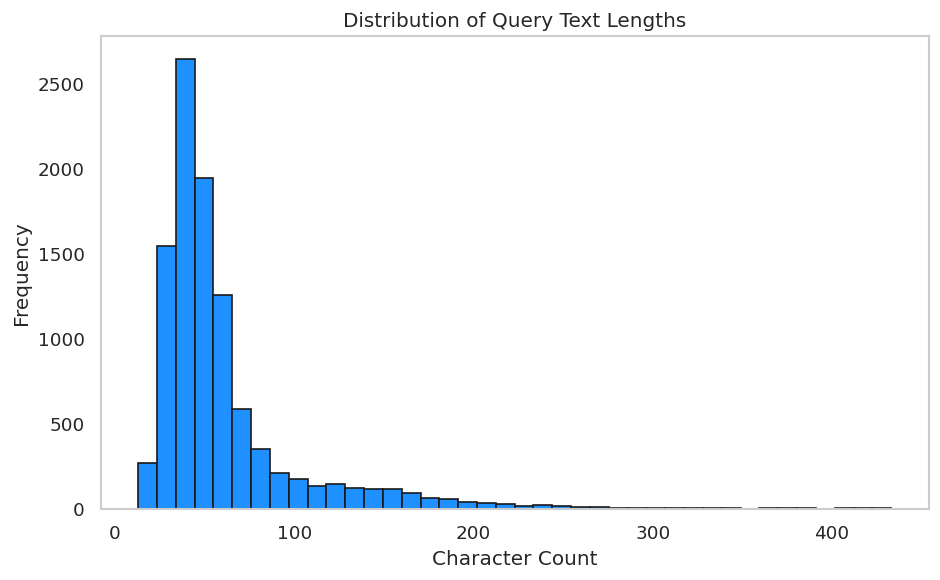

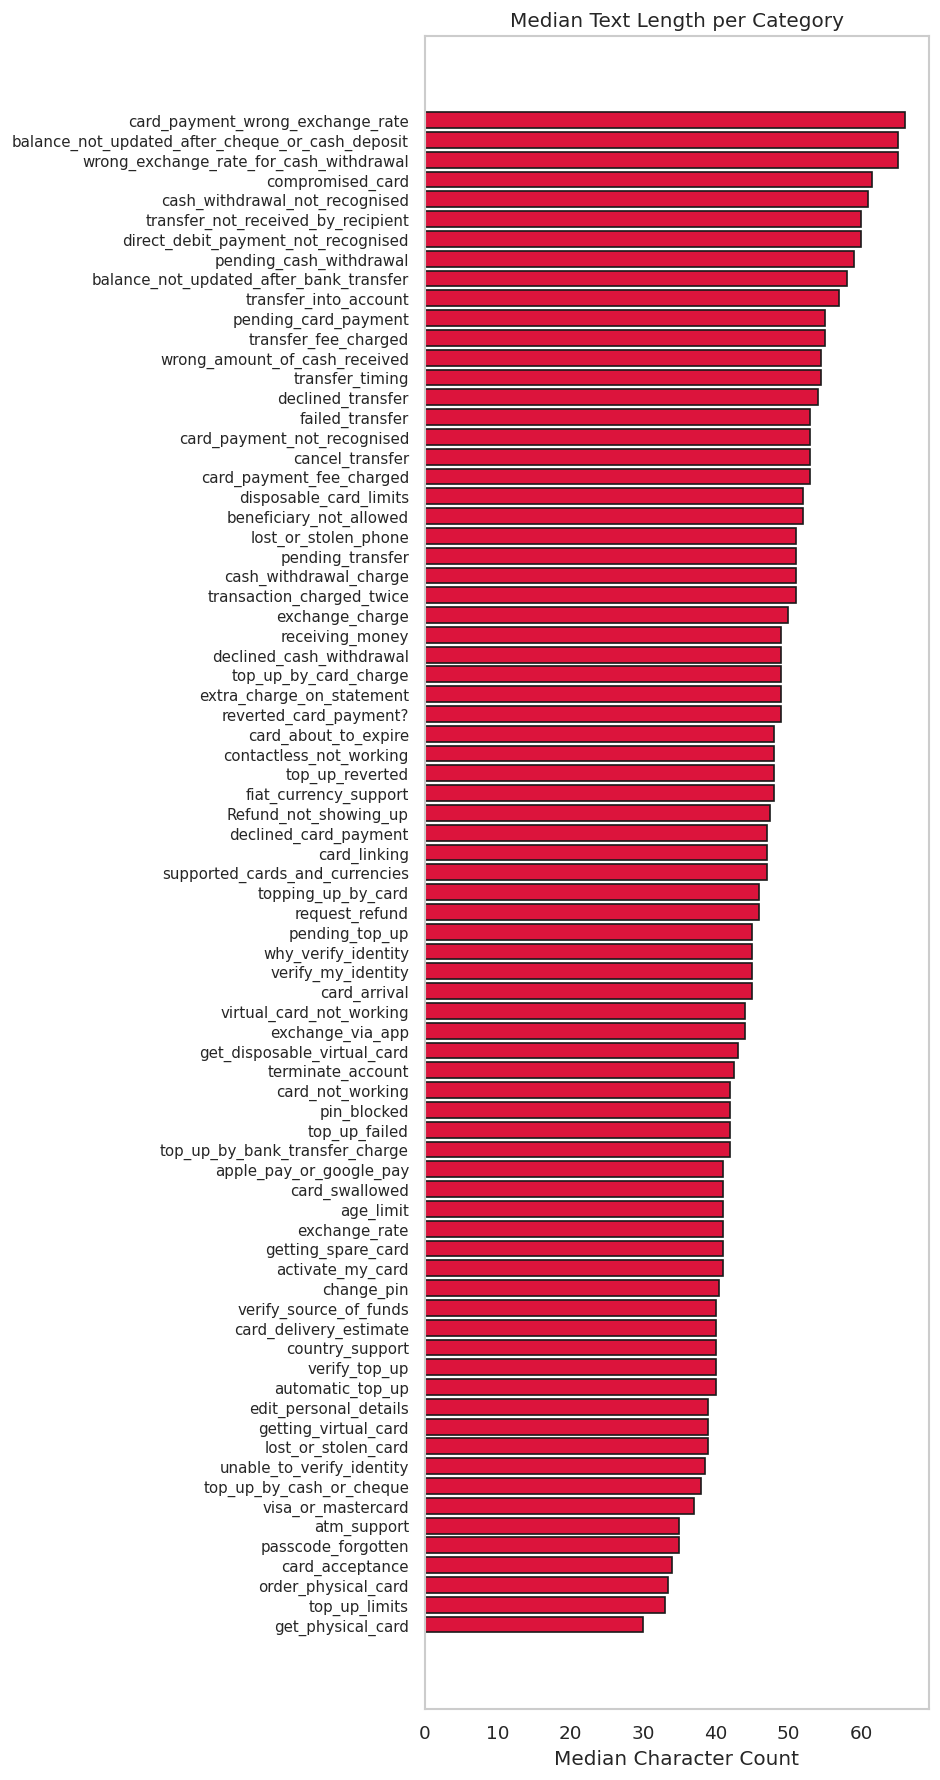

count    10003.000000
mean        59.475057
std         40.867716
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: text_length, dtype: float64


In [12]:
# Analyze text length across categories

train_df["text_length"] = train_df["text"].str.len()
test_df["text_length"] = test_df["text"].str.len()


fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(train_df['text_length'], bins=40, color='dodgerblue', edgecolor='k')
ax.set_title("Distribution of Query Text Lengths")
ax.set_xlabel("Character Count")
ax.set_ylabel("Frequency")
ax.grid(False)

plt.tight_layout()
plt.show()

median_lengths = train_df.groupby('category')['text_length'].median().sort_values()

fig, ax = plt.subplots(figsize=(8, 15))
ax.barh(range(len(median_lengths)), median_lengths.values, color='crimson', edgecolor='k')
ax.set_yticks(range(len(median_lengths)))
ax.set_yticklabels(median_lengths.index, fontsize=9)
ax.set_title("Median Text Length per Category")
ax.set_xlabel("Median Character Count")
ax.grid(False)
plt.tight_layout()
plt.show()

print(train_df['text_length'].describe())

### Finding: Text Length Analysis

- Median queries are short (around 47 characters)
- Distribution is right-skewed (because the majority of queries are short in character length)
- Some outliers for queries greater than 200 characters
- Categories with larger text queries include `card_payment_fee_charged`, `direct_debit_payment_not_recognised`, etc. Might point to more detailed steps being involved for the consumer. 
- Categories with shorter text queries include `contactless_not_working`, `virtual_card_not_working`, etc. Implie these tend to be simpler, more direct requests.

In [13]:
# Top words per category

# common words that carry little meaning for intent classification
stopwords = set([
    'i', 'me', 'my', 'the', 'a', 'an', 'is', 'it', 'to', 'do',
    'in', 'of', 'and', 'or', 'for', 'can', 'how', 'what', 'why',
    'when', 'will', 'if', 'was', 'be', 'has', 'have', 'are', 'on',
    'at', 'this', 'that', 'not', 'with', 'from', 'by', 'we', 'you',
    'your', 'there', 'they', 'their', 'so', 'about', 'would', 'could',
    'get', 'got', 'just', 'been', 'did', 'its', 'am', 'up', 'out',
    'but', 'no', 'as', 'into', 'which', 'more', 'also', 'any', 'all'
])

def top_words(df, category, n=10):
    '''Extract the most frequnecy words for a given category. Filters
    out common stopwords to focus on more meaningful terms. Part of EDA.
    
    Args:
        df (pd.DataFrame): The dataframe containing the `text` and `category` 
                            columns.
        
        category (str): The category for which to extract top words.
        
        n (int): Number of top words to return. Defaults to 10.
        
        Returns:
        
            list[tuple[str, int]]: A list of (word, count) tuples sorted by frequency
                                in descending order.
    '''
        
    # Filter dataframe beloning to the specified category class and lowercase the text
    # for comparision
    texts = df[df['category'] == category]['text'].str.lower()
    
    # Tokenize each query into indivduals words using regex
    words = [w for text in texts for w in re.findall(r'\b[a-z]{3,}\b', text) if w not in stopwords]
    
    # Count word frequencies and return the top n most common words
    return Counter(words).most_common(n)


# Picking 5 cateogries that represent a mix of banking problems
sample_categories = [
    'card_arrival',                          # card delivery issue
    'lost_or_stolen_card',                   # card security issue
    'exchange_rate',                         # currency inquiry
    'transfer_not_received_by_recipient',    # transfer problem
    'verify_my_identity',                    # account verification
    'balance_not_updated_after_bank_transfer' # balance discrepancy
]


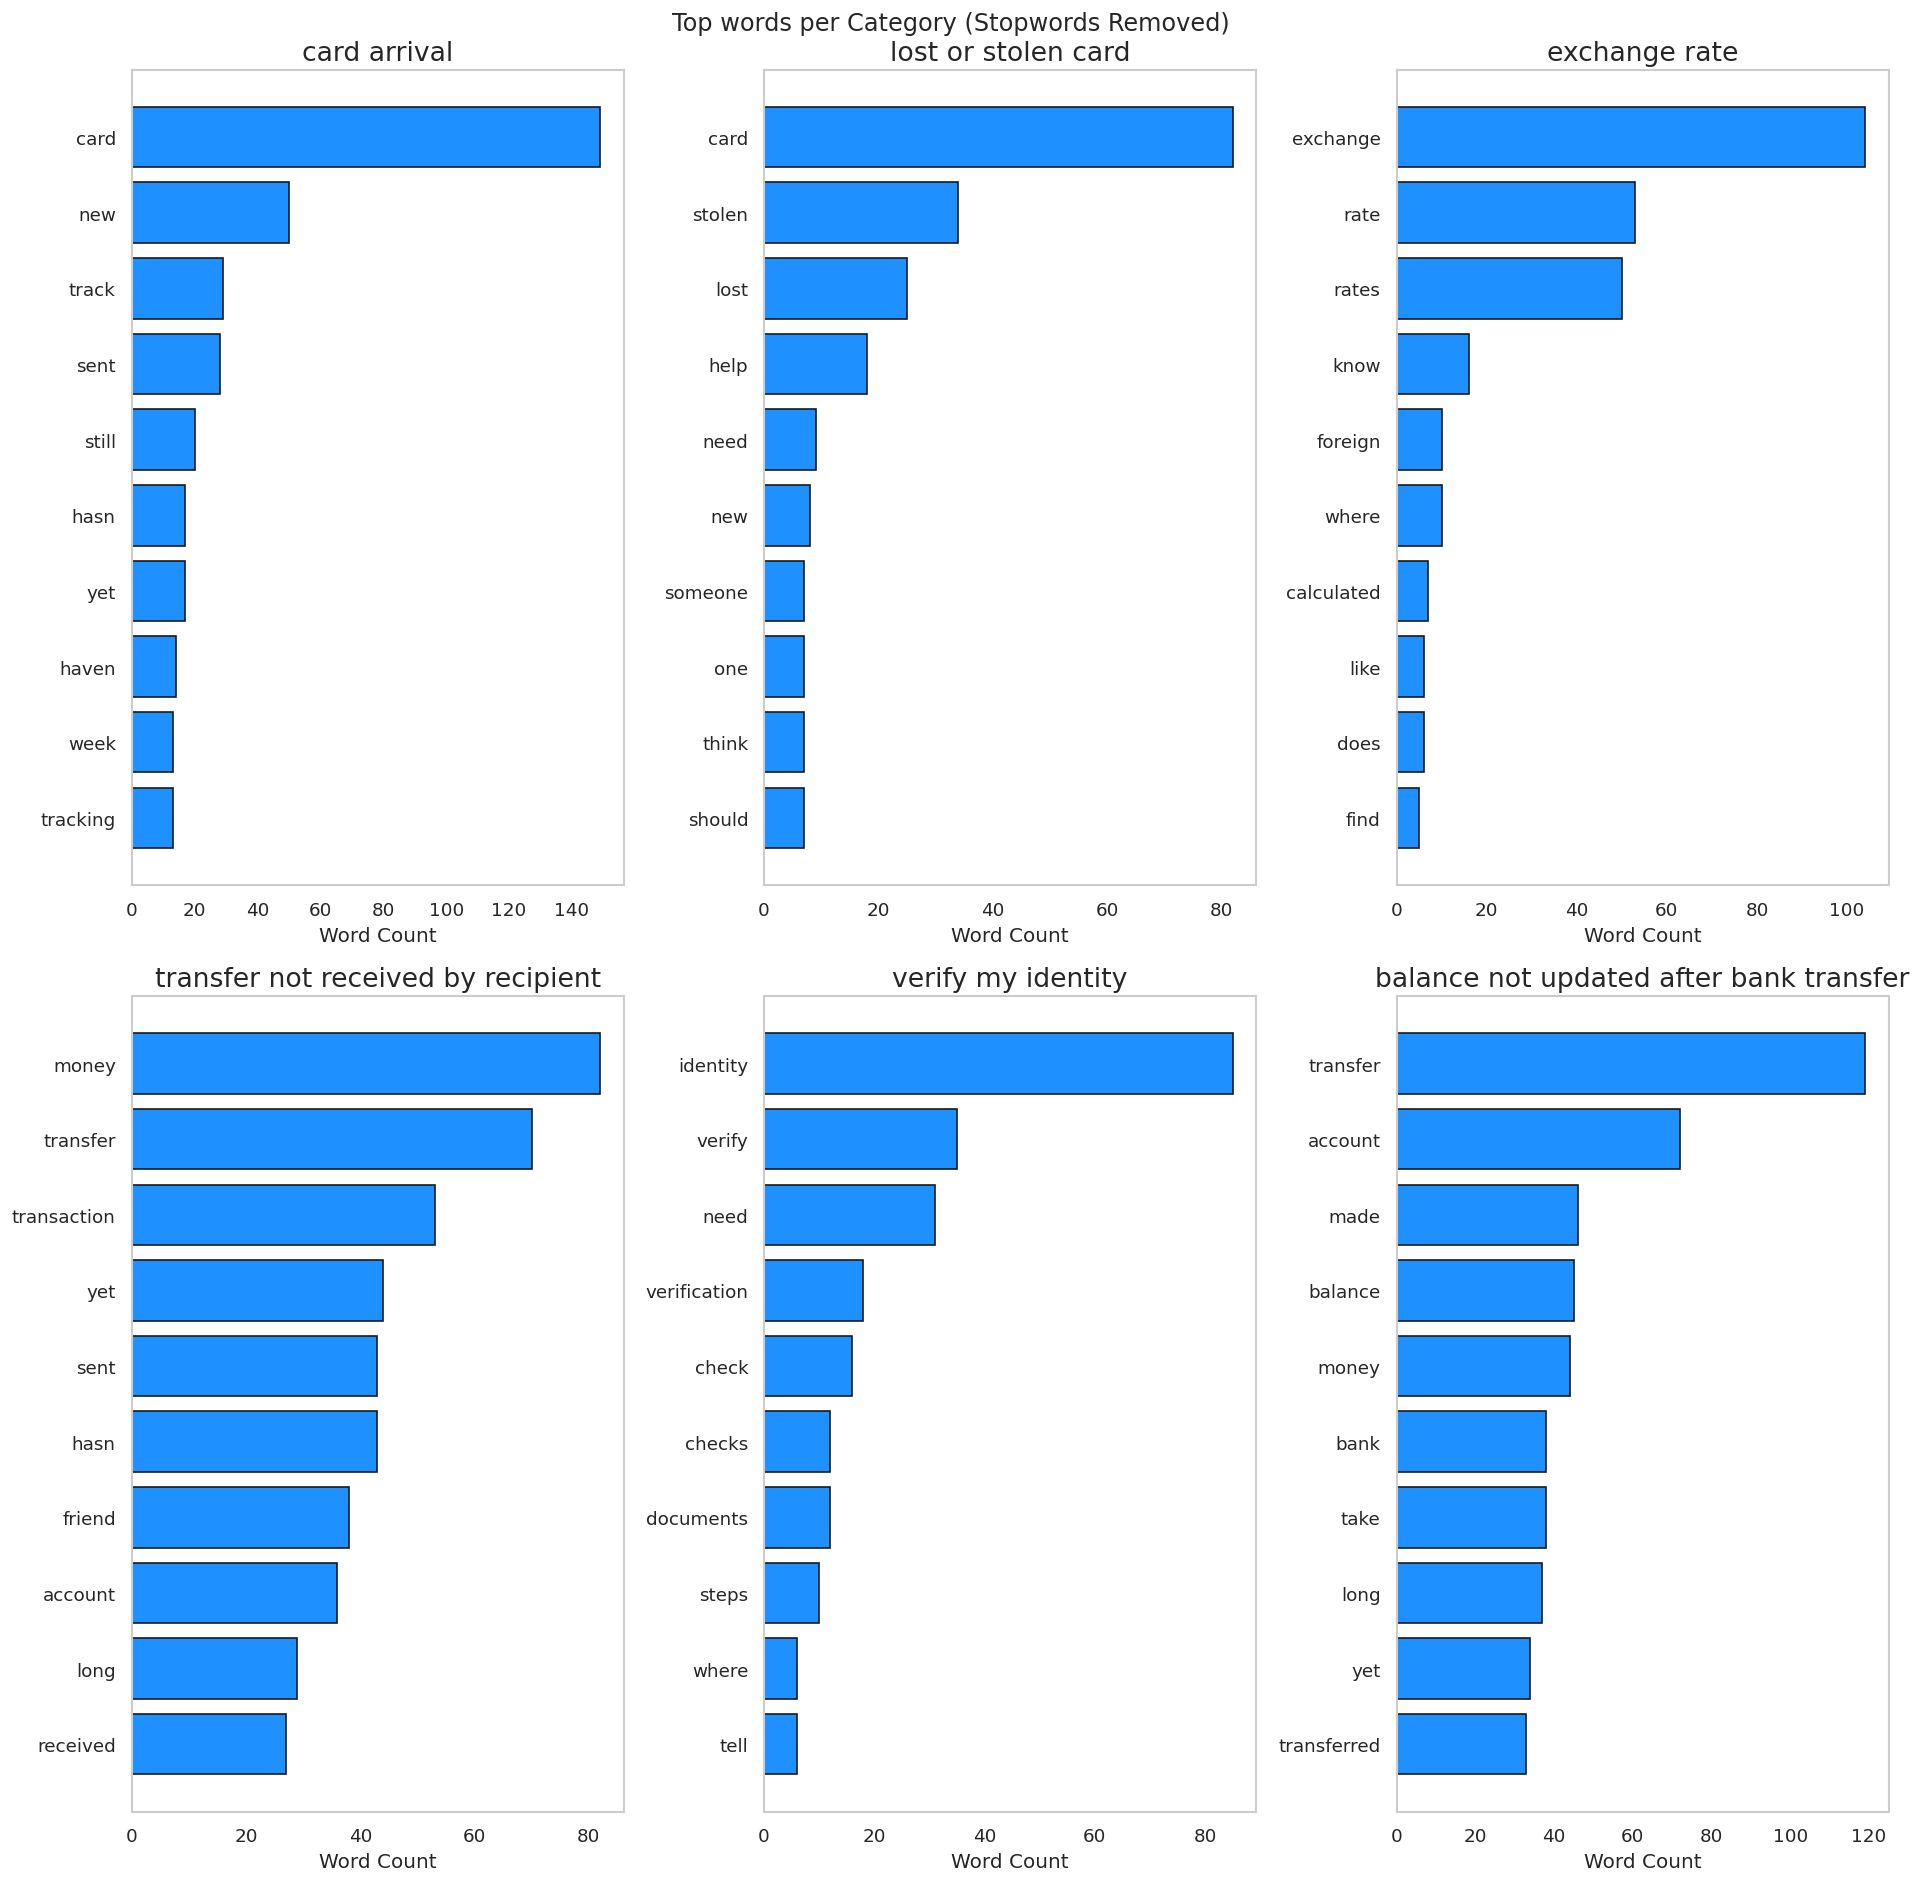

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16,16))
axes = axes.flatten() 

for i, intent in enumerate(sample_categories):
    
    
    words, counts = zip(*top_words(train_df, intent))

    axes[i].barh(words, counts, color='dodgerblue', edgecolor='k')

    axes[i].set_title(intent.replace('_', ' '), fontsize=16)

    axes[i].invert_yaxis()
    axes[i].set_xlabel("Word Count")
    axes[i].grid(False)

plt.suptitle("Top words per Category (Stopwords Removed)")

plt.tight_layout()
plt.show()

### Findings: Top Words per Category Class

- Each category class has different vocabulary clusters. For example, `card_arrival` is dominated by words such as `card`, `new`, `track` while `exhange_rate` is dominated by words like `exchange`, `rate`, and `rates`.
- Common words that appear across chosen categories: `card`, `transfer`, `account`

## Phase 3: Data Preparation

I will prep the data for the MLP baseline and the RoBERTa transfirner.

**Steps:**
- Encode queries from text strings to integers (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html)
- **MLP Prep:** vectorize query text; PyTorch dataframe
- **RoBERTa Prep:** Tokenize query text.

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import RobertaTokenizer, DataCollatorWithPadding


# Confirm GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [19]:
def encode_labels(train_df, test_df):
    ''' Encode category labels into integers using LabelEncoder. Fits a LabelEncorder
    on the training set and applies the same encoding to the test set to ensure consistency.
    Ensures consistent label IDs across both splits.
    
    Args:
        train_df (pd.DataFrame): The training dataframe containing a `category` column.
        
        test_df (pd.DataFrame): The test dataframe containing a `category` column.  
        
    Returns:
        tuple: (train_labels, test_labels, label_encoder) where:
            - train_labels (np.ndarray): Encoded integer labels for the training set.
            - test_labels (np.ndarray): Encoded integer labels for the test set.
            - label_encoder (LabelEncoder): The fitted LabelEncoder instance for reference. 
    '''

    label_encoder = LabelEncoder()
    
    # fit training labels only
    train_labels = label_encoder.fit_transform(train_df['category'])
    
    # transform test labels using the same encoder
    test_labels = label_encoder.transform(test_df['category'])
    
    return train_labels, test_labels, label_encoder



# Encode the category labels
train_labels, test_labels, label_encoder = encode_labels(train_df, test_df)

print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Sample encoding for 'card_arrival': {label_encoder.transform(['card_arrival'])[0]}")
print(f"Sample encoding for 'lost_or_stolen_card': {label_encoder.transform(['lost_or_stolen_card'])[0]}")
print(f"Sample decoding for label 0: {label_encoder.inverse_transform([0])[0]} ")
print(f"Train labels shape: {train_labels.shape}, Test labels shape: {test_labels.shape}")

Number of classes: 77
Sample encoding for 'card_arrival': 12
Sample encoding for 'lost_or_stolen_card': 42
Sample decoding for label 0: Refund_not_showing_up 
Train labels shape: (10003,), Test labels shape: (3080,)


### MLP Preprocessing using TF-IDF Vectorization

TF-IDF (Term Frequency-Inverse Document Frequency) is a statistical method to evaluate how important a text query is in relation to the larger collection. See [information here for more detail.](https://www.geeksforgeeks.org/machine-learning/understanding-tf-idf-term-frequency-inverse-document-frequency/). In short, TF measures the frequency of a particular word; higher frequency indicates greater signficance/importance. 

    TF(t, d) = (Number of times text t appears in document d / total number of terms in document d).

IDF is the opposite. It focuses on the importance of rarer words, raising their improortance. If a term is less frequency, then it is more meaningful and specific.

    IDF(t,D) = log[ Total number of documents in collection D / Number of documetns containg text t ].

So, the TF-IDF score is the product of TF and IDF:

    TF - IDF(t, d, D) = TF(t, d) x IDF(t, D).

In [20]:
def vectorize_text(train_df, test_df):
    ''' Vectorize the `text` column of the training and test dataframes using TfidfVectorizer 
    for the MLP baseline model. Fits a TD-IDF vectorizer on the training text and transforms 
    both training and test text using the same vectorizer to ensure consistent feature 
    representation. Vectorize is fitted only on trained data only.
    
    Args:
        train_df (pd.DataFrame): The training dataframe containing a `text` column.
        
        test_df (pd.DataFrame): The test dataframe containing a `text` column.
        
    Returns:
        tuple: (X_train, X_test, vectorizer) where:
            - X_train (sparse matrix): TF-IDF vectorized features for the training set.
            - X_test (sparse matrix): TF-IDF vectorized features for the test set       
            - vectorizer (TfidfVectorizer): The fitted TfidfVectorizer instance for reference.
    '''
    
    vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True)
    
    # Fit on training text and transform on training text only
    X_train = vectorizer.fit_transform(train_df['text'])
    
    # Transform test text using the same vectorizer
    X_test = vectorizer.transform(test_df['text'])
    
    return X_train, X_test, vectorizer


# Apply TF-IDF vectorization to the text data
X_train_tfidf, X_test_tfidf, tfidf_vectorizer = vectorize_text(train_df, test_df)

print(f"Train TF-IDF shape: {X_train_tfidf.shape}, Test TF-IDF shape: {X_test_tfidf.shape}")
print(f"Vocabulary size:    {len(tfidf_vectorizer.vocabulary_)}")
print(f"Sample features: {list(tfidf_vectorizer.get_feature_names_out())[:10]}")

Train TF-IDF shape: (10003, 10000), Test TF-IDF shape: (3080, 10000)
Vocabulary size:    10000
Sample features: ['00', '00 in', '000', '10', '10 minutes', '10 pounds', '100', '100 all', '100 but', '18']


### Finding: TD-IDF Vectorization

- each query is now a 10,000 dimensional numerical vector
- chose `max_features` as 10,000 for a starting point for the hyperparameter. Seems like a good number considering the shape of the training dataset.

### PyTorch DataLoader

TF-IDF produces a sparse matrix. PyTorch needs a dense tensor. Need to create a custom dataset in PyTorch (https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html) and retrieve it with `DataLoader`.


In [21]:
class BankingDataset(Dataset):
    ''' PyTorch custom dataset class for TD-IDF vectorized banking queries.
    Converts a sparse matrix of TF-IDF features and corresponding labels into 
    a format suitable for training a PyTorch model. 
    
    Args:
        features (sparse matrix): A sparse matrix of TF-IDF features of shape
                                    (n_samples, n_features).
        
        labels (np.ndarray): An array of integer-encoded category labels 
                                corresponding to the features of shape (n_samples,).
    '''
    
    def __init__(self, features, labels):
        '''Initialize dataset.
        
        Args:
            features (sparse matrix): A sparse matrix of TF-IDF features of shape
                                        (n_samples, n_features).
            
            labels (np.ndarray): An array of integer-encoded category labels 
                                    corresponding to the features of shape (n_samples,).
        '''
        # convert sparse matrix to dense tensor for PyTorch compatibility
        self.features = torch.tensor(features.toarray(), dtype=torch.float32)
        
        # labels need to be int64 tensors
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        ''' Return total number of samples in the dataset.
        
        Returns:
            int: The number of samples in the dataset. 
        '''
        return len(self.labels)

    def __getitem__(self, idx):
        ''' Retrieve a single sample by index. Called by the DataLoader
        during training to get batches of data.
        
        Args:
            idx (int): The index of the sample to retrieve.
            
        Returns:
            tuple: (feature, label) where:
                - feature (torch.Tensor): The TF-IDF feature vector for the 
                                            sample of shape (n_features,).
                - label (torch.Tensor): The integer-encoded category label as
                                            a scalar tensor. 
        '''
        return self.features[idx], self.labels[idx]

In [ ]:
# Instantiate the dataset objects for training and test sets
train_dataset = BankingDataset(X_train_tfidf, train_labels)
test_dataset = BankingDataset(X_test_tfidf, test_labels)

# Wrap in DataLoaders for batched training and evaluation
# batch_size = 32 will produce ~10,003/32 ≈ 313 batches per epoch for training 
# and ~3,000/32 ≈ 94 batches for testing
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # set shuffle=True for training to randomize order each epoch
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # set shuffle=False for evaluation to maintain consistent order

print(f"Train dataset shape: {len(train_dataset)}, Test dataset shape: {len(test_dataset)}")
print(f"Train batches per epoch: {len(train_loader)}, Test batches: {len(test_loader)}")

# Inspect one batch to confirm tensor shapes
sample_features, sample_labels = next(iter(train_loader))
print(f"Sample batch features shape: {sample_features.shape}, Sample batch labels shape: {sample_labels.shape}")

Train dataset shape: 10003, Test dataset shape: 3080
Train batches per epoch: 313, Test batches: 97
Sample batch features shape: torch.Size([32, 10000]), Sample batch labels shape: torch.Size([32])


### RoBERTa Preprocessing: Tokenization

RoBERTa (Robustly Optimized BERT Pretraining Approach) is a transformer-based language model that improves upon BERT. See more details [here](https://huggingface.co/papers/1907.11692). Hugging Face documentation can be found [here](https://huggingface.co/docs/transformers/model_doc/roberta).

Unlike TF-IDF which converts text to word frequency vectors, RoBERTa requires text to be converted into subword token IDS using its own tokenizer.

In [25]:
class RobertaDataset(Dataset):
    ''' PyTorch custom dataset class for tokenized text queries for RoBERTa
    model finetuning. Tokenizes raw text queries using a RoBERTa tokenizer 
    and stores input IDs and attention masks as tensors for model input. 
    Also encodes category labels as long tensors for compatibility with
    CrossEntropyLoss during training.
    
    Args:
        texts (pd.Series): A pandas Series of raw customer query strings.
        
        labels (np.ndarray): Integer-encorded category labels.
                                
        tokenizer (RobertaTokenizer): A pre-initialized RoBERTa tokenizer for
                                        tokenizing the text data.
                                           
        max_length (int): Maximum token sequence length. Defaults to 256.
    '''
    
    def __init__(self, texts, labels, tokenizer, max_length=256):
        '''Tokenize all texts on initialization and store as tensors. 
        
        Args:
            texts (pd.Series): A pandas Series of raw customer query strings.
            
            labels (np.ndarray): Integer-encorded category labels.
                                    
            tokenizer (RobertaTokenizer): A pre-initialized RoBERTa tokenizer for
                                            tokenizing the text data.
            
            max_length (int): Maximum token sequence length. Defaults to 256.
        '''
        
        self.labels = torch.tensor(labels, dtype=torch.long)
        
        # Tokenize all queries at once using batch tokenization for efficiency
        # Dynmamic padding with DataCollatorWithPadding
        self.encodings = tokenizer(list(texts), truncation=True, max_length=max_length, padding=False, return_tensors=None)
    
    
    def __len__(self):
        ''' Return total number of samples in the dataset.
        
        Returns:
            int: The number of samples in the dataset. 
        '''
        return len(self.labels)
    
    def __getitem__(self, idx):
        ''' Retrieve a single tokenized sample by index. Returns a dictionary
        format required by Hugging Face's trainer, where the inputs_ids and 
        attention_mask are the minimum required keys for the model input.
        
        Args:
            idx (int): The index of the sample to retrieve. 
            
        Returns:
            dict: {
                'input_ids' (list[int]): token ID sequence,
                'attention_mask' (list[int]): 1 for real tokens, 0 for padding,
                'labels' (torch.Tensor): integer intent label
            }
        '''
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

In [26]:
# load the pretrained RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Instantiate RoBERTa datasets
train_roberta_dataset = RobertaDataset(train_df['text'], train_labels, tokenizer, max_length=256)
test_roberta_dataset = RobertaDataset(test_df['text'], test_labels, tokenizer, max_length=256)

# dynamic padding: pads each batch only to the length of its longest sequence
# rather than the global max_length. This is more efficient and reduces unnecessary padding tokens.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Train RoBERTa dataset shape: {len(train_roberta_dataset)}, Test RoBERTa dataset shape: {len(test_roberta_dataset)}")

sample = train_roberta_dataset[0]
print(f"Sample input_ids: {sample['input_ids'][:10]}... (length: {len(sample['input_ids'])})")
print(f"Sample attention_mask: {sample['attention_mask'][:10]}... (length: {len(sample['attention_mask'])})")
print(f"Sample label: {sample['labels']} (decoded: {label_encoder.inverse_transform([sample['labels'].item()])[0]})")  



Train RoBERTa dataset shape: 10003, Test RoBERTa dataset shape: 3080
Sample input_ids: [0, 100, 524, 202, 2445, 15, 127, 1886, 116, 2]... (length: 10)
Sample attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]... (length: 10)
Sample label: 12 (decoded: card_arrival)


## Data Preparation Summary

| Step | MLP | RoBERTa |
|------|-----|---------|
| Dataset class | `BankingDataset` | `RobertaDataset` |
| Padding | TF-IDF is fixed size | Dynamic per batch via `DataCollatorWithPadding` |
| Max length | N/A | 256 tokens |
| Batching | `DataLoader` batch size 32 | Hugging Face `Trainer` handles this |

## Phase 4: Modeling

Now, I will build and train these two models:

1. **MLP Baseline:** A simple feedforward neural network trained on TF-IDF features.
2. **RoBERTa:** A pretrained transformer finetuned by Low-Rank Adaption (LoRA) from Hugging Face.

For more information on the general architechure of building ML models, see https://docs.pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html.

### MLP (Multi-layer Perceptron)

For more information on MLP, see [here](https://machine-learning-tutorial-abi.readthedocs.io/en/latest/content/deep_learning/mlp.html). It will taken the 10k dimensional TF-IDF vector for each query and pass it through two hidden layers with ReLU activations before producing a probability distribution over the 77 category classes.

**Architecture:**
- Input Layer: 10,000 neurons (one per each TF-IDF feature)
- Hidden Layer 1: 512 neurons + ReLU + Dropout
- Hidden Layer 2: 256 neurons + ReLU + Dropout
- Output Layer: 77 neurons (one per category class)

ReLU activation will introduce non-linearity so that the network does not collapse into a single linear transformation.

In [27]:
import torch.nn as nn


class MLPClassifier(nn.Module):
    ''' Multi-layer Perceptron for banking classification. It will take the
    TF-IDF vectorized features as input and output class probabilities for 
    the 77 categories. Serves as the baseline moedl to compare against the
    finetuned RoBERTa model.
    
    Architecture:
        Input (10,000 features) -> Hidden Layer (512 units, ReLU) -> Output Layer (77 classes)
        
    Args:
        input_dim (int): Dimensionality of the input features (10,000 for TF-IDF).
        
        hidden_dim_1 (int): The number of units in the first hidden layer.
        
        hidden_dim_2 (int): The number of units in the second hidden layer.
        
        output_dim (int): The number of output classes to predict.
         
        dropout (float): Dropout rate applied after each hidden layer.  
    '''
    
    def __init__(self, input_dim=10000, hidden_dim_1=512, hidden_dim_2=256, output_dim=77, dropout=0.3):
        '''Initialize the MLP architecture with two hidden layers and dropout regularization.
        
        Args:
            input_dim (int): Dimensionality of the input features (10,000 for TF-IDF).
            
            hidden_dim_1 (int): First hidden layer size. Defaults to 512.
            
            hidden_dim_2 (int): Second hidden layer size. Defaults to 256.
            
            output_dim (int): Number of classes. Defaults to 77.
            
            dropout (float): Dropout probability. Defaults to 0.3. This dropout
                                rate deactivates 30% of neurons during training 
                                to help prevent overfitting.
        '''
        
        super(MLPClassifier, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_1, hidden_dim_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim_2, output_dim)
        )



    def forward(self, x):
        '''Forward pass through the network.
        
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, input_dim).
            
        Returns:
            torch.Tensor: Output tensor of shape (batch_size, output_dim).
                            Pass through softmax to get class probabilities.
        '''
        return self.network(x)

In [28]:
# Instantiate the model
model = MLPClassifier(input_dim=10000, hidden_dim_1=512, hidden_dim_2=256, output_dim=77, dropout=0.3).to(device)

print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

MLPClassifier(
  (network): Sequential(
    (0): Linear(in_features=10000, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=77, bias=True)
  )
)
Total parameters: 5271629
Trainable parameters: 5271629


### Finding: MLP Architecture

- 5.27M total trainable parameters

### Loss Function and Optimizer

Before training, set up:
1. **Loss Function:** measures how wrong the model's predictions are
2. **Optimizer:** updates model weights to reduce that loss

In [29]:
# Loss Function - CrossEntropyLoss, which is standard choice for multi-class classification problems. 
# combines log-softmax and negative log-likelihood into a single function
criterion = nn.CrossEntropyLoss()

# Optimizer - AdamW, Adam with a decoupled weight decay regularization term
# useful doe neural network classification
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")
print(f"Weight decay: {optimizer.param_groups[0]['weight_decay']}")

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Learning rate: 0.001
Weight decay: 0.0001


### MLP Training Loop

This training loop will run for a fixed number of epochs. Each epoch will consistent of two pases:

1. **Training phase:** forward pass, loss calculation, backward pass, weight update. Model is in `train()` mode so dropout is active.
2. **Validation phase:** forward pass only, no weight updates. Model is in `eval()` mode so dropout is disabled for consistent predictions.

Per epoch, I will track loss and accuracy to monitor progress.

In [36]:
def train_mlp(model, train_loader, criterion, optimizer, device, epochs=10):
    ''' Train the MLP classifier on the banking training set. Run a standard
    supervised training loop for a fixed number of epochs. Each epoch performs
    a full forward and backward pass over all training batches, then evaluates
    on the training set to track learning progress.
    
    Args
        model (nn.Module): The MLP model to train.
        
        train_loader (DataLoader): Batched training data.
                                    
        criterion (nn.CrossEntropyLoss): The loss function to optimize.
        
        optimizer (torch.optim.AdamW): Optimizer for weight updates.
        
        device (torch.device): The device to run training on, e.g. 'cuda' or 'cpu'.
        
        epochs (int): Number of full passes over the training data. Defaults to 10.
                        
    Returns:
        list[dict]: A history of training metrics per epoch, where each entry is a
                        dictionary containing 'epoch', 'loss', and 'accuracy' keys. 
    '''
    
    history = []
    
    for epoch in range(epochs):
        
        # set model to traning model to enable dropout for regularization
        model.train()
        
        total_loss = 0.0
        correct = 0
        total = 0
        
        for batch_features, batch_labels in train_loader:
            
            # Move batch to GPU
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            
            # Zero graduaents from previous step
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(batch_features)
            
            # Compute loss between predicted logits and true labels
            loss = criterion(logits, batch_labels)
            
            # Backward pass to compute gradients via backpropagation
            loss.backward()
            
            # Update model weights using computed gradients
            optimizer.step()
            
            # Track Metrics
            total_loss += loss.item()
            predicted_labels = logits.argmax(dim=1)
            correct += (predicted_labels == batch_labels).sum().item()
            total += batch_labels.size(0)
            
        # Compute epoch level metrics
        avg_loss = total_loss / len(train_loader)
        accuracy = correct / total
        
        history.append( {
            'epoch': epoch + 1,
            'loss': avg_loss,
            'accuracy': accuracy
        })
        
        print(f"Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.4f} | Train Accuracy: {accuracy:.4f}")
    
    return history

def plot_training_history(history):
    """Plot training loss and accuracy curves over epochs. Visualizes 
    the learning progression of the MLP to identify convergence behavior, 
    potential overfitting, or underfitting. A good training run shows 
    decreasing loss and increasing accuracy that both plateau toward the 
    final epochs.

    Args:
        history (list[dict]): Training history returned by train_mlp(),
                                containing 'epoch', 'loss', and 'accuracy' 
                                per epoch.
    """
    epochs   = [h['epoch'] for h in history]
    losses   = [h['loss'] for h in history]
    accs     = [h['accuracy'] for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss curve
    axes[0].plot(epochs, losses, marker='o', color='dodgerblue',
                 linewidth=2, markersize=5)
    axes[0].set_title("MLP Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_xticks(epochs)
    axes[0].grid(False)

    # Accuracy curve
    axes[1].plot(epochs, accs, marker='o', color='crimson',
                 linewidth=2, markersize=5)
    axes[1].set_title("MLP Training Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_xticks(epochs)
    axes[1].set_ylim(0, 1)
    axes[1].grid(False)

    plt.suptitle("MLP Training Curves", fontsize=13)
    plt.tight_layout()
    plt.show()


In [31]:
# Train the MLP model
# epoch = 1- should be sufficient for convergence
print("Training MLP model...")
history = train_mlp(model=model, train_loader=train_loader, criterion=criterion, optimizer=optimizer, device=device, epochs=10)

Training MLP model...
Epoch 1/10 | Loss: 2.8019 | Train Accuracy: 0.3335
Epoch 2/10 | Loss: 0.6081 | Train Accuracy: 0.8387
Epoch 3/10 | Loss: 0.2392 | Train Accuracy: 0.9401
Epoch 4/10 | Loss: 0.1302 | Train Accuracy: 0.9666
Epoch 5/10 | Loss: 0.0820 | Train Accuracy: 0.9803
Epoch 6/10 | Loss: 0.0510 | Train Accuracy: 0.9883
Epoch 7/10 | Loss: 0.0408 | Train Accuracy: 0.9894
Epoch 8/10 | Loss: 0.0299 | Train Accuracy: 0.9923
Epoch 9/10 | Loss: 0.0211 | Train Accuracy: 0.9950
Epoch 10/10 | Loss: 0.0169 | Train Accuracy: 0.9962


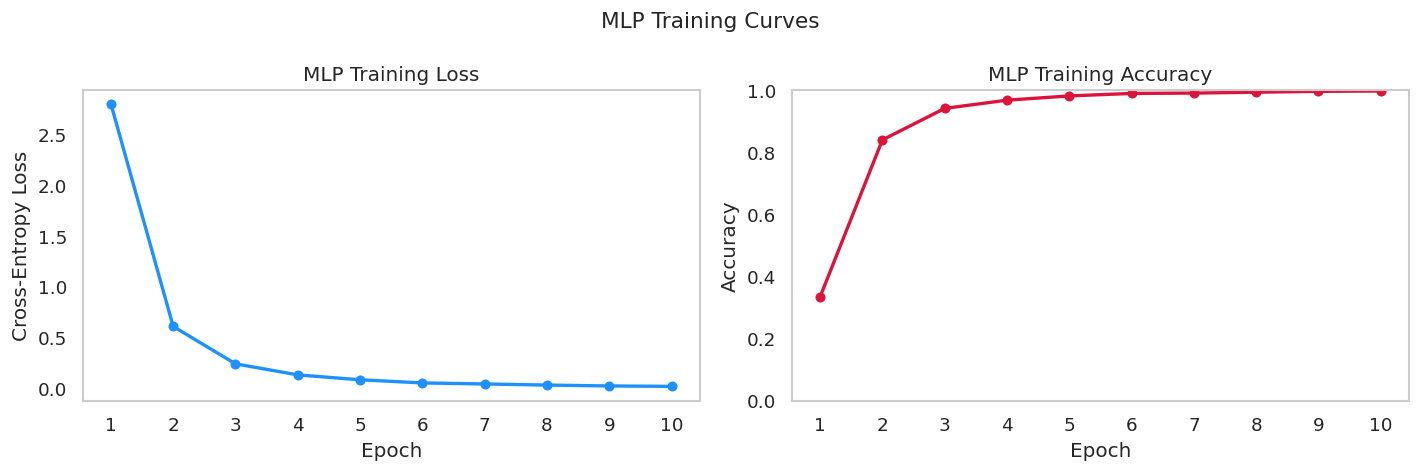

In [37]:
plot_training_history(history)

### Findings: Initial Training of MLP

- Loss decreases sharply in the first 3 epochs then plateaued. Shows that it convered wtihin 10 epoches.
- Training accuracy reached around 99.6% by the 10th epoch.
- Model could be overfitted. Should this be expected?  the TF-IDF + MLP is trained on short text, and the model has not understanding of word context so it compensates by memorizing surface-level patterns.

In [39]:
def evaluation_mlp(model, test_loader, device, label_encoder):
    ''' Evaluate the trained MLP model on the test set. Run a single forward
    pass over all test batches with dropout disables, collecting predictions 
    and true labels for metric calculation. No gradient computation is performed
    as only inference is needed during evaluation.
    
    Args:
        model (MLPClassifier): Trained MLP model.
        
        test_loader (DataLoader): Batched test data.
        
        device (torch.device): Device to run inference on.
        
        label_encoder (LabelEncoder): Fitted encoder to decode integer predictions 
                                        back to class names.
                                        
    Returns:
        tuple: (all_preds, all_labels) where:
            - all_preds (list[int]): List of predicted class indices for the test set.
            - all_labels (list[int]): List of true class indices for the test set.
    '''
    
    # Set model to eval mode, which disables dropout and other training-specific layers
    model.eval()
    
    all_preds = []
    all_labels = []
    
    # disable gradient computation
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            
            # Move batch to GPU
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)
            
            # Forward pass to get logits
            logits = model(batch_features)
            
            # Get predicted class by taking the argmax of the logits
            predicted_labels = logits.argmax(dim=1)
            
            all_preds.extend(predicted_labels.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
        
    return all_preds, all_labels

In [41]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Run evaluation on the test set
mlp_preds, mlp_labels = evaluation_mlp(model, test_loader, device, label_encoder)

# metrics calculation
mlp_accuracy = accuracy_score(mlp_labels, mlp_preds)
mlp_macro_f1 = f1_score(mlp_labels, mlp_preds, average='macro')
mlp_weighted_f1 = f1_score(mlp_labels, mlp_preds, average='weighted')

print("MLP Performance on Test Set:\n")
print(f"Accuracy: {mlp_accuracy:.4f}")
print(f"Macro F1 Score: {mlp_macro_f1:.4f}")
print(f"Weighted F1 Score: {mlp_weighted_f1:.4f}")


# Per class classification report

print("\nClassification Report:\n")
print(classification_report(mlp_labels, mlp_preds, target_names=label_encoder.classes_))

MLP Performance on Test Set:

Accuracy: 0.8886
Macro F1 Score: 0.8891
Weighted F1 Score: 0.8891

Classification Report:

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.90      0.93      0.91        40
                                activate_my_card       0.97      0.97      0.97        40
                                       age_limit       0.98      1.00      0.99        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.95      0.90      0.92        40
                                automatic_top_up       1.00      0.90      0.95        40
         balance_not_updated_after_bank_transfer       0.71      0.72      0.72        40
balance_not_updated_after_cheque_or_cash_deposit       0.90      0.93      0.91        40
                         beneficiary_not_allowed       0.95      0.9

### Finding: MLP Test Set Performance

**Overall Metrics:**
- Accuracy: 88.9%
- Macro F1: 0.889
- Weighted F1: 0.889


Strong performers are:
- `apple_pay_or_google_pay`, `age_limit`, `activate_my_card`, etc

Weakest performers are:
- `balance_not_updated_after_bank_transfer`, `why_verify_identity`, etc.

### LoRA-RoBERTa Finetuning

In this part, I will finetune the `roberta-base` using LoRA (Low-Rank Adapation). LoRA will decompose weight updates into two small matrices to reduce compute and memory requirements.

In [43]:
from peft import LoraConfig, get_peft_model, TaskType
from transformers import (
    RobertaForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Load the pretrained RoBERTa model for classification
base_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=77, ignore_mismatched_sizes=True)

# Configure LoRA for parameter-efficient fine-tuning
# using commin values
lora_config = LoraConfig(task_type=TaskType.SEQ_CLS, r=16, lora_alpha=32, lora_dropout=0.1, target_modules=["query", "value"], bias="none")

# Apply LoRA configuration to the base model to create a LoRA-augmented model
lora_model = get_peft_model(base_model, lora_config)

# Compare parameter counts
total_params = sum(p.numel() for p in lora_model.parameters())
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)

print(f"Total parameters in LoRA model: {total_params}")
print(f"Trainable parameters in LoRA model: {trainable_params}")    
print(f"Percentage of trainable parameters: {trainable_params / total_params * 100:.2f}%")

lora_model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters in LoRA model: 125944474
Trainable parameters in LoRA model: 1239629
Percentage of trainable parameters: 0.98%
trainable params: 1,239,629 || all params: 125,944,474 || trainable%: 0.9843


### Finding: LoRA Configuration

- only 1239629/125944474 ~ 0.98% parameters are trainable

### LoRA-RoBERTa Training Configuration

Hugging Face's `Trainer` will handle the training loop, evaluation, and checkpointing automatically. `TrainingArguments` allows for configuration of parameters in the finetuning process.

In [44]:
def compute_metrics(eval_pred):
    '''Compute the accuracy and macro F1 score for the RoBERTa model predictions.
    Called automatically by the Hugging Face Trainer after each evaluation phase. 
    Returns metrics that are logged and used to identify the best model checkpoint.
    
    Args:
        eval_pred (EvalPrediction): Named tuple containing:
            - predictions (np.ndarray): Raw logits of shape (n_samples, n_classes)
            - label_ids (np.ndarray): True integer labels of shape (n_samples,)

    Returns:
        dict: {
            'accuracy': float — overall accuracy across all intent classes,
            'macro_f1': float — unweighted mean F1 across all 77 classes
        }
    '''
    
    logits, labels = eval_pred
    
    # convert logits to predicted class indices
    predictions = np.argmax(logits, axis=-1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'macro_f1': f1_score(labels, predictions, average='macro'),
    }

In [49]:
# Configure fine-tuning training arguments for the Hugging Face Trainer
training_args = TrainingArguments(
    output_dir="./roberta_lora_banking", # directory to save model checkpoints and logs
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,                 # number of steps for learning rate warmup
    weight_decay=0.01,                # strength of weight decay regularization
    learning_rate=2e-4,              # oonly updating LoRA adapter weights
    eval_strategy="epoch",      # evaluate at the end of each epoch
    save_strategy="epoch",            # save model checkpoint at the end of each epoch
    
    load_best_model_at_end=True,      # load the best model found during training at the end
    metric_for_best_model="macro_f1", # use macro F1 score to determine the best model
    
    logging_dir="./logs",              # directory for storing logs
    logging_steps=50,              # log training metrics every 50 steps
    report_to="none"
)


# Instantiate Trainer
trainer = Trainer(
    model=lora_model,
    args=training_args,
    train_dataset=train_roberta_dataset,
    eval_dataset=test_roberta_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


print("Trainer Configured with the following training arguments:\n")
print(f"Training samples: {len(train_roberta_dataset)}, Evaluation samples: {len(test_roberta_dataset)}")
print(f"Batch size: {training_args.per_device_train_batch_size}, Epochs: {training_args.num_train_epochs}")
print(f"Learning rate: {training_args.learning_rate}, Weight decay: {training_args.weight_decay}")
print(f"Evaluation strategy: {training_args.eval_strategy}, Save strategy: {training_args.save_strategy}")
print(f"Best model metric: {training_args.metric_for_best_model}")


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer Configured with the following training arguments:

Training samples: 10003, Evaluation samples: 3080
Batch size: 16, Epochs: 5
Learning rate: 0.0002, Weight decay: 0.01
Evaluation strategy: IntervalStrategy.EPOCH, Save strategy: SaveStrategy.EPOCH
Best model metric: macro_f1


In [50]:
# Finetune LoRA-RoBERTa
print("Finetuning LoRA-RoBERTa...\n")
trainer.train()

Finetuning LoRA-RoBERTa...



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.725348,0.557057,0.856818,0.853033
2,0.431046,0.358292,0.897727,0.897620
3,0.314596,0.294091,0.918182,0.918207
4,0.265637,0.272593,0.923377,0.923509
5,0.230324,0.264998,0.924675,0.924782


TrainOutput(global_step=3130, training_loss=0.6647313148449785, metrics={'train_runtime': 303.444, 'train_samples_per_second': 164.824, 'train_steps_per_second': 10.315, 'total_flos': 1010147528499252.0, 'train_loss': 0.6647313148449785, 'epoch': 5.0})

In [51]:
# Generate predictions on the test set using the best model checkpoint
print("Evaluating LoRA-RoBERTa on test set...\n")
roberta_preds_output = trainer.predict(test_roberta_dataset)

# extract logits and convert to predicted class indices
roberta_logits = roberta_preds_output.predictions
roberta_preds = np.argmax(roberta_logits, axis=-1)
roberta_true = roberta_preds_output.label_ids

# metrics calculation
roberta_accuracy = accuracy_score(roberta_true, roberta_preds)
roberta_macro_f1 = f1_score(roberta_true, roberta_preds, average='macro')
roberta_weighted_f1 = f1_score(roberta_true, roberta_preds, average='weighted')

print("\nLoRA-RoBERTa Performance on Test Set:\n")
print(f"Accuracy: {roberta_accuracy:.4f}")
print(f"Macro F1 Score: {roberta_macro_f1:.4f}")
print(f"Weighted F1 Score: {roberta_weighted_f1:.4f}")


# Per class classification report
print("\nClassification Report:\n")
print(classification_report(roberta_true, roberta_preds,    target_names=label_encoder.classes_))

Evaluating LoRA-RoBERTa on test set...




LoRA-RoBERTa Performance on Test Set:

Accuracy: 0.9247
Macro F1 Score: 0.9248
Weighted F1 Score: 0.9248

Classification Report:

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up       0.98      1.00      0.99        40
                                activate_my_card       0.97      0.95      0.96        40
                                       age_limit       1.00      1.00      1.00        40
                         apple_pay_or_google_pay       1.00      1.00      1.00        40
                                     atm_support       0.98      1.00      0.99        40
                                automatic_top_up       0.97      0.93      0.95        40
         balance_not_updated_after_bank_transfer       0.72      0.72      0.72        40
balance_not_updated_after_cheque_or_cash_deposit       0.97      0.95      0.96        40
                         beneficiary_not_allowed       0.9

### Finding: LoRA-RoBERTa Test Set Performance

Overall metrics:
- Accuracy: 92.5%
- Macro F1: 0.925
- Weighted F1: 0.925

Strongest performers were:
-  `Refund_not_showing_up`, `age_limit`, `cancel_transfer`, etc

In [52]:
# Save finetuned LoRA-RoBERTa model and tokenizer for future inference
save_path = "./roberta_lora_banking_final" 

lora_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to {save_path}")


for f in os.listdir(save_path):
    print(f)   

Model saved to ./roberta_lora_banking_final
README.md
tokenizer.json
tokenizer_config.json
adapter_model.safetensors
adapter_config.json


## Phase 5: Evaluation & Model Comparision

Here, I will compare the MLP baseline against the LoRA-RoBERTa across all 77 category calsses to understand where the added complexity of a transformer is justified and where both models perform similarly.

In [53]:
# classification reports as dictionaries

mlp_report = classification_report(
    mlp_labels, mlp_preds, target_names=label_encoder.classes_, output_dict=True
)
roberta_report = classification_report(
    roberta_true, roberta_preds, target_names=label_encoder.classes_, output_dict=True
)

# Extract per class metrics into Dataframes
mlp_df = pd.DataFrame(mlp_report).T 
roberta_df = pd.DataFrame(roberta_report).T

# Keep only the 77 categories
exclude_rows = ['accuracy', 'macro avg', 'weighted avg']
cat_classes = [c for c in label_encoder.classes_ if c not in exclude_rows]

mlp_text = mlp_df.loc[cat_classes, ['precision', 'recall', 'f1-score']]
roberta_text = roberta_df.loc[cat_classes, ['precision', 'recall', 'f1-score']]

# build comparision dataframe
comparison_df = pd.DataFrame({
    'mlp_f1': mlp_text['f1-score'],
    'roberta_f1': roberta_text['f1-score'],
    'mlp_precision': mlp_text['precision'],
    'roberta_precision': roberta_text['precision'],
    'mlp_recall': mlp_text['recall'],
    'roberta_recall': roberta_text['recall']
})

# Calculate differences
# Positive means that RoBERTa outperformed MLP, Negative means MLP outperformed RoBERTa
comparison_df['f1_diff'] = comparison_df['roberta_f1'] - comparison_df['mlp_f1']
comparison_df['precision_diff'] = comparison_df['roberta_precision'] - comparison_df['mlp_precision']
comparison_df['recall_diff'] = comparison_df['roberta_recall'] - comparison_df['mlp_recall']

# Sort by F1 score difference to identify which categories had the biggest performance changes
comparison_df = comparison_df.sort_values(by='f1_diff', ascending=False)

print("\n Top 10 Categories where RoBERTa outperformed MLP:\n")
print(comparison_df[['mlp_f1', 'roberta_f1', 'f1_diff']].head(10).round(3).to_string())

print("\n Bottom 10 Categories where MLP outperformed RoBERTa:\n")
print(comparison_df[['mlp_f1', 'roberta_f1', 'f1_diff']].tail(10).round(3).to_string())

print(f"Text where RoBERTa improved: {(comparison_df['f1_diff'] > 0).sum()}")
print(f"Text where MLP improved: {(comparison_df['f1_diff'] < 0).sum()}")
print(f"Text where performance was the same: {(comparison_df['f1_diff'] == 0).sum()}")



 Top 10 Categories where RoBERTa outperformed MLP:

                                         mlp_f1  roberta_f1  f1_diff
unable_to_verify_identity                 0.810       0.962    0.152
order_physical_card                       0.776       0.900    0.124
top_up_failed                             0.810       0.927    0.117
extra_charge_on_statement                 0.850       0.962    0.112
card_acceptance                           0.815       0.923    0.108
card_not_working                          0.818       0.925    0.107
card_payment_not_recognised               0.810       0.914    0.103
reverted_card_payment?                    0.815       0.916    0.101
wrong_exchange_rate_for_cash_withdrawal   0.850       0.947    0.097
why_verify_identity                       0.773       0.865    0.092

 Bottom 10 Categories where MLP outperformed RoBERTa:

                             mlp_f1  roberta_f1  f1_diff
activate_my_card              0.975       0.962   -0.013
card_swallowed    